In [20]:
%matplotlib widget
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pybaselines import Baseline, utils
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import os 
import glob
from galvani import BioLogic as BL
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio # For Plotly themes 

# Function for reading files

In [21]:
def read_data(file_name):
    legend_temp = []
    data_line_temp = []
    time_stamp_temp = []
    data_storing = False
    print(f"Reading file: {file_name}")
    with open(file_name, 'r') as file:
        for line in file:
            if 'q(A-1)' in line:
                data_storing = True
                continue
            if 'Comment' in line:
                legend_temp = line.split()[4]
            if 'Date' in line:
                time_stamp_temp = line.split()[2] 
            if data_storing:
                data_line_temp.append(line.strip())
    df_temp= pd.DataFrame([line.split() for line in data_line_temp])
    df_temp= df_temp.astype(float)

    return legend_temp, time_stamp_temp ,df_temp

    

# Function for finding timestamps

In [22]:
def find_nearest_time(target_time, discharge_start_time, total_cycle_time, time_dict):
    new_time_dict = {}

    base_time = datetime.strptime(time_dict[1], '%Y-%m-%dT%H:%M:%S')

    for key in time_dict:
        current_time = datetime.strptime(time_dict[key], '%Y-%m-%dT%H:%M:%S')
        time_difference = (current_time - base_time).total_seconds()
        new_time_dict[time_difference] = key
#     print(new_time_dict)
    nearest_time_difference = min(new_time_dict, key=lambda x: abs(x - target_time))
    nearest_key = new_time_dict[nearest_time_difference]
    
    discharge_time_difference = min(new_time_dict, key=lambda x: abs(x - (target_time+discharge_start_time)))
    discharge_key = new_time_dict[discharge_time_difference]
    
    furthest_time_difference = min(new_time_dict, key=lambda x: abs(x - (target_time+total_cycle_time)))
    furthest_key = new_time_dict[furthest_time_difference]
    
    return nearest_key, discharge_key, furthest_key, new_time_dict

# Read all the files

In [24]:
os.chdir(r'.\data\Test_data\20240604_2503-SKJB_6MECDEC_100volHFE')
file_list = glob.glob('*_1_*.dat')

legend = {} #Dictionary for storing the comments from experiment data files to be used as legends later
time_stamp = {} #Dictionary to store the time of file creation
key = 0
file_dictionary = {} # Dictionary for storing all the pandas data file 

# Read all the files data from the directory and also the comments and file generation time in seperate pd dataframe

for data_file in file_list:
    key += 1
    legend[key], time_stamp[key], file_dictionary[key] = read_data(data_file)

    
print('Number of files:',key)

FileNotFoundError: [WinError 3] The system cannot find the path specified: '.\\data\\Test_data\\20240604_2503-SKJB_6MECDEC_100volHFE'

In [ ]:
pio.templates.default = "simple_white"
fig = go.Figure()
for key in file_dictionary:
    X_data = file_dictionary[key].iloc[:,0]
    Y_data = file_dictionary[key].iloc[:,1]
    fig.add_trace(go.Scatter(x = X_data, y = Y_data))

fig.show()

# Read EC lab files 

Indices for cycle change: [0, 4402, 6478, 8651, 10492, 12416, 14293]


Text(0, 0.5, 'Potential (V)')

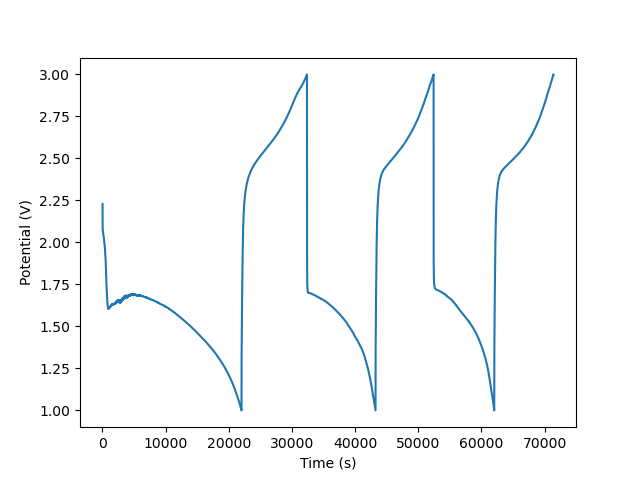

In [19]:
mpr = BL.MPRfile('./2503-SKJB-1pt07mg_6MECDEC_100volHFE-1_C02.mpr')

elec_df_temp = pd.DataFrame(mpr.data)
#print(elec_df_temp)

    # Filter the data for the OCV from the dataframe 
filter = elec_df_temp['Ns'] != 0
elec_df = elec_df_temp[filter]
elec_df.to_csv('electrochem_datafile.txt', sep = '\t')

    # Track the diffent times for charge-discharge by noting when the Ns value changes

cycle_change_index = []
cycle_change_index.append(0)
for index in range(len(elec_df['Ns'])-1):
    if elec_df['Ns'].iloc[index] != elec_df['Ns'].iloc[index+1]:
        cycle_change_index.append(index)
cycle_change_index.append(index+1) #Takes the index for the last file also  
print("Indices for cycle change:", cycle_change_index)

    # Plot the read electrochemical file
Elec_Xdata = elec_df['time/s']
Elec_Ydata = elec_df['Ewe/V']
plt.figure()
plt.plot(Elec_Xdata,Elec_Ydata)
plt.xlabel('Time (s)')
plt.ylabel('Potential (V)')

# Data Segregation

In [ ]:
print('Total number of cycles:', len(cycle_change_index)//2)

# Filter the DataFrame by the condition
starting_cycle = int(input("Starting cycle to plot:"))
end_cycle = int(input("Final cycle to plot:"))

# Initial and final line numbers for the chosen cycle to plot:
initial_line = cycle_change_index[2*starting_cycle-2]
change_cycle_line = cycle_change_index[2*starting_cycle-1]
final_line = cycle_change_index[2*end_cycle]
print('\nBiologic data file line details:')
print('initial_line,change_cycle_line, final_line:',initial_line,change_cycle_line, final_line)

elec_df_2 = elec_df.iloc[initial_line:final_line]
elec_df_2.to_csv('electrochem_datafile2.txt', sep = '\t')

time_when_change = elec_df.iloc[change_cycle_line].loc['time/s']
print("\ntime when cycle change:",time_when_change)


# Reference times to segregate SAXS data files
ref_time = int(elec_df_2['time/s'].iloc[0] - elec_df['time/s'].iloc[0])
total_cycle_time = int(elec_df_2['time/s'].iloc[-1] - int(elec_df_2['time/s'].iloc[0]))
discharge_start_time = int(time_when_change - elec_df_2['time/s'].iloc[0])
print()
print(f'Ref. time, relative discharge start and Total cycle time:{ref_time}s, {discharge_start_time} and {total_cycle_time}s\n')

# find the corresponding starting abd ending SAXS file
starting_file, discharge_file, last_file, new_time_dict  = find_nearest_time(ref_time, discharge_start_time, total_cycle_time, time_stamp)

print(f"Starting SAXS file no.: {starting_file}")
print(f"Discharge SAXS file no.: {discharge_file}")
print(f"Last SAXS file no.: {last_file}\n")
print('Time stamps:')
print('Initial file:',time_stamp[starting_file], "Discharge file:",time_stamp[discharge_file],'Last file:', time_stamp[last_file])

# For Baseline correction (manually select the first long exposure file)

In [5]:

background_file = glob.glob('*_Al_WAXS.dat')
for input in background_file:
    a1,a2,background = read_data(input)


Reading file: beckground_with_Al_WAXS.dat


# Creating the background (With a average over the first three files)

[0.00571908 0.00580312 0.00588656 ... 0.00319505 0.00320272 0.00321075]


(-0.001, 0.008)

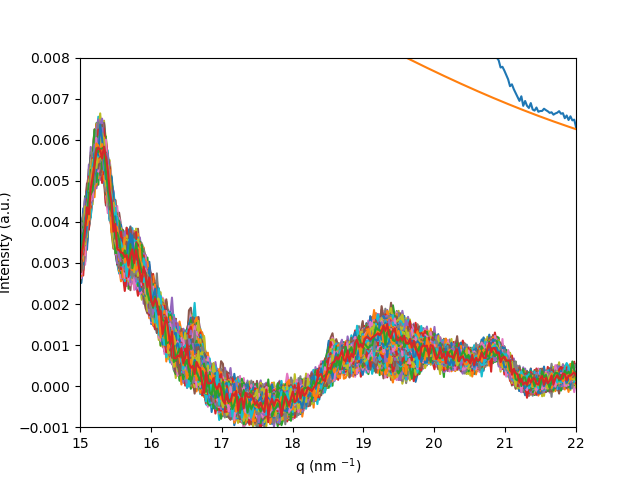

In [4]:

X_data = []
Y_data = []

# Create a average over the first three data files 

for files in range(1,4):
    if files == 1:
        X_data = 10*file_dictionary[files].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        Y_data = file_dictionary[files].iloc[:,1]
    else:
        x = 10*file_dictionary[files].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        y = file_dictionary[files].iloc[:,1]
        X_data += x
        Y_data += y

for entries in range(len(X_data)):
    X_data[entries] = X_data[entries]/3
    Y_data[entries] = Y_data[entries]/3

baseline_filter = Baseline(x_data = X_data)
baseline = baseline_filter.modpoly(Y_data, poly_order= 6)[0]
print(baseline)
modified_Y = Y_data-baseline
plt.plot(X_data, Y_data)
plt.plot(X_data, baseline)
plt.plot(X_data, modified_Y)

# Create new file dictionary with corrected spectra
corrected_waxs_files = {}
for ikey in file_dictionary:
    X_data = 10*file_dictionary[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[ikey].iloc[:,1]
    modified_Y = Y_data - baseline
    plt.plot(X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    corrected_waxs_files[ikey] = df

#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.xlim(15,22)
plt.ylim(-0.001,0.008)

(-0.0006, 0.002)

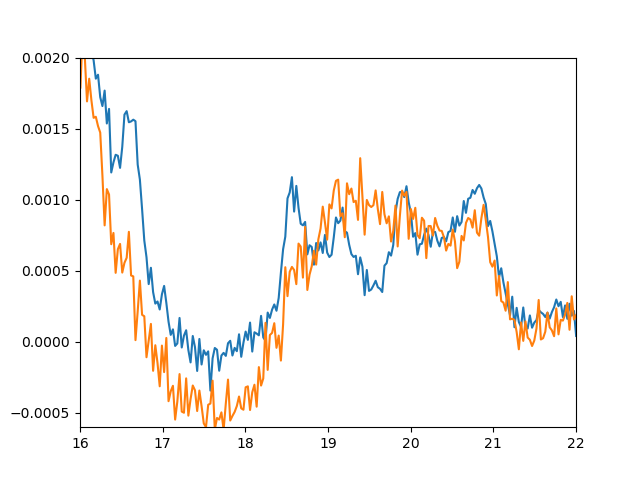

In [15]:
plt.figure()
plt.plot(corrected_waxs_files[1].iloc[:,0], corrected_waxs_files[1].iloc[:,1])
plt.plot(corrected_waxs_files[1].iloc[:,0], corrected_waxs_files[100].iloc[:,1])
plt.xlim(16,22)
plt.ylim(-0.0006,0.002)